In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # 用于显示进度条
from FireCube_dataloader import FireCubeLoader

# 1. 必须先把特征列表定义出来（与你训练时保持完全一致）
dynamic_features = [
    '1 km 16 days NDVI',
    'LST_Day_1km',
    'LST_Night_1km',
    'era5_max_d2m',
    'era5_max_t2m',
    'era5_max_sp',
    'era5_max_tp',
    'sminx',
    'era5_max_wind_speed',
    'era5_min_rh'
]

static_features = [
    'dem_mean',
    'slope_mean',
    'roads_distance',
    'waterway_distance',
    'population_density'
]

clc_features = ['clc_' + str(c) for c in range(10)]

# 2. 初始化专门用于分析的 DataLoader
# 【注意】is_scale=False, is_aug=False 保证原始物理数值，且必须传入上面定义的三个 features！
eda_data = FireCubeLoader(
    root='./datasets/datasets_grl/npy/spatiotemporal', 
    mode='train', 
    is_scale=False, 
    is_aug=False, 
    is_shuffle=True, 
    seed=42,
    dynamic_features=dynamic_features,   # ✅ 补充传入动态特征
    static_features=static_features,     # ✅ 补充传入静态特征
    clc_features=clc_features            # ✅ 补充传入土地覆盖特征
)
# 2. 准备容器收集中心像素 [12, 12] 的数据
pos_dynamic_target_day = [] # 正样本，目标日的所有动态特征
neg_dynamic_target_day = [] 
pos_sminx_10d = []          # 正样本，10天的土壤湿度序列 (特征索引为7)
neg_sminx_10d = []
pos_clc = []                # 正样本，中心点CLC
neg_clc = []
months = []
labels = []

# 为了画图速度，我们抽取 5000 个样本（你也可以设为全集 len(eda_data)）
num_samples = len(eda_data)

print(f"正在从 {num_samples} 个样本中提取中心像素特征用于可视化...")
for i in tqdm(range(num_samples)):
    data_static, data_dynamic, data_clc, label, data_time = eda_data[i]
    _, month, _ = eda_data.get_time(i)
    
    months.append(month)
    labels.append(label)
    
    # 提取中心点 [12, 12] 的数据
    if label == 1:
        pos_dynamic_target_day.append(data_dynamic[:, 0, 12, 12]) # 取第10天(索引9)的所有动态特征
        pos_sminx_10d.append(data_dynamic[7, :, 12, 12])          # 取10天的 sminx (索引7)
        pos_clc.append(data_clc[:, 12, 12])
    else:
        neg_dynamic_target_day.append(data_dynamic[:, 0, 12, 12])
        neg_sminx_10d.append(data_dynamic[7, :, 12, 12])
        neg_clc.append(data_clc[:, 12, 12])

# 转为 numpy 方便处理
pos_dynamic_target_day = np.array(pos_dynamic_target_day)
neg_dynamic_target_day = np.array(neg_dynamic_target_day)
pos_sminx_10d = np.array(pos_sminx_10d)
neg_sminx_10d = np.array(neg_sminx_10d)
pos_clc = np.array(pos_clc)
neg_clc = np.array(neg_clc)

正在从 40554 个样本中提取中心像素特征用于可视化...


100%|██████████| 40554/40554 [01:21<00:00, 499.12it/s]


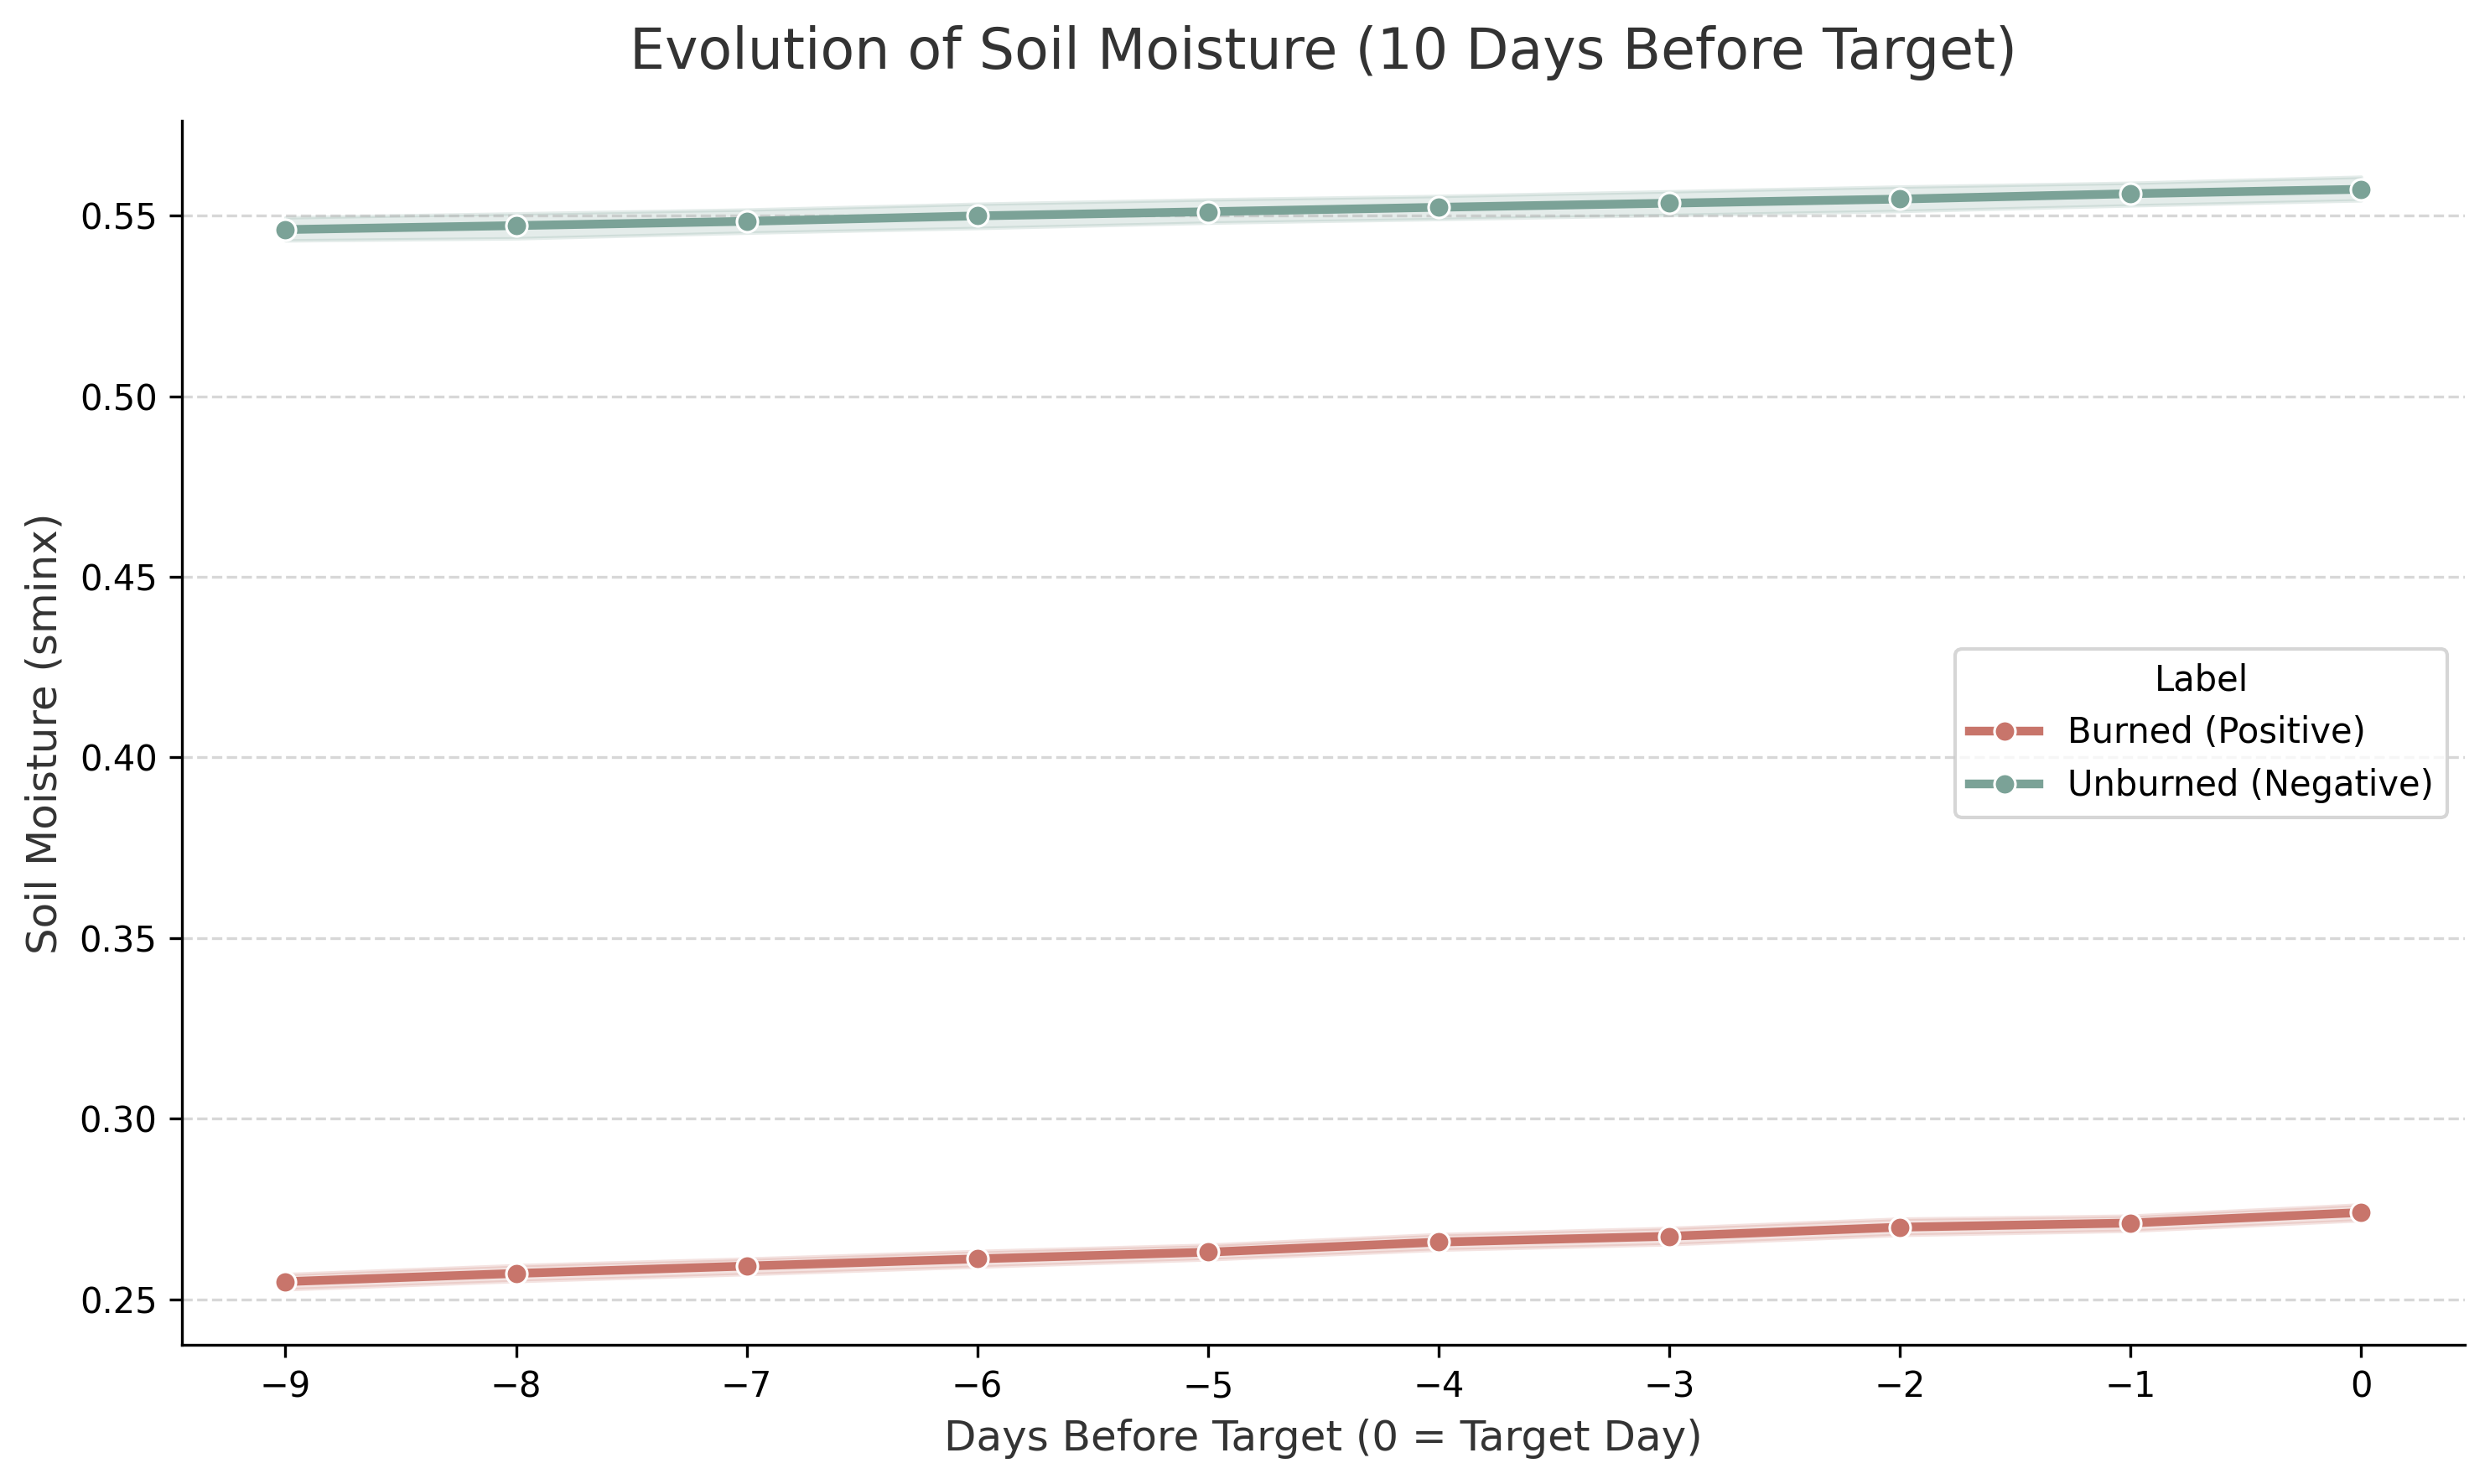

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 构建正确的时间轴：从起火前 9 天 (-9) 到 起火当天 (0)
time_steps = np.arange(-9, 1)

# 2. 将 Numpy 数组转换为 Seaborn 喜欢的“长格式 DataFrame”
# 正样本处理
df_pos = pd.DataFrame(pos_sminx_10d, columns=time_steps)
df_pos_melt = df_pos.melt(var_name='Days Before Target', value_name='Soil Moisture (sminx)')
df_pos_melt['Label'] = 'Burned (Positive)'

# 负样本处理
df_neg = pd.DataFrame(neg_sminx_10d, columns=time_steps)
df_neg_melt = df_neg.melt(var_name='Days Before Target', value_name='Soil Moisture (sminx)')
df_neg_melt['Label'] = 'Unburned (Negative)'

# 合并数据
df_ts = pd.concat([df_pos_melt, df_neg_melt], ignore_index=True)

# 3. 开始绘制高颜值时间序列图
plt.figure(figsize=(10, 6), dpi=300)

# 使用高级的莫兰迪配色
academic_palette = {"Burned (Positive)": "#C8756B", "Unburned (Negative)": "#7BA297"}

# sns.lineplot 会自动计算每个时间点的均值，并画出 95% 置信区间阴影
ax = sns.lineplot(
    data=df_ts, 
    x='Days Before Target', 
    y='Soil Moisture (sminx)', 
    hue='Label', 
    palette=academic_palette,
    marker='o',         # 在每个数据点上打上圆点，增加数据颗粒感
    linewidth=2.5,      # 加粗线条
    errorbar='ci'       # 默认画出置信区间，代表数据的波动范围
)

# 4. 图表美化与排版
plt.title('Evolution of Soil Moisture (10 Days Before Target)', fontsize=16, pad=15, color='#333333')
plt.xlabel('Days Before Target (0 = Target Day)', fontsize=12, color='#333333')
plt.ylabel('Soil Moisture (sminx)', fontsize=12, color='#333333')

# 强制规定 X 轴刻度，确保 -9 在最左边，0 在最右边，符合时间流逝常识
plt.xticks(np.arange(-9, 1, 1))

# 添加虚线网格，方便对齐查看趋势
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 去掉上方和右侧的边框
sns.despine()

plt.tight_layout()
plt.show()

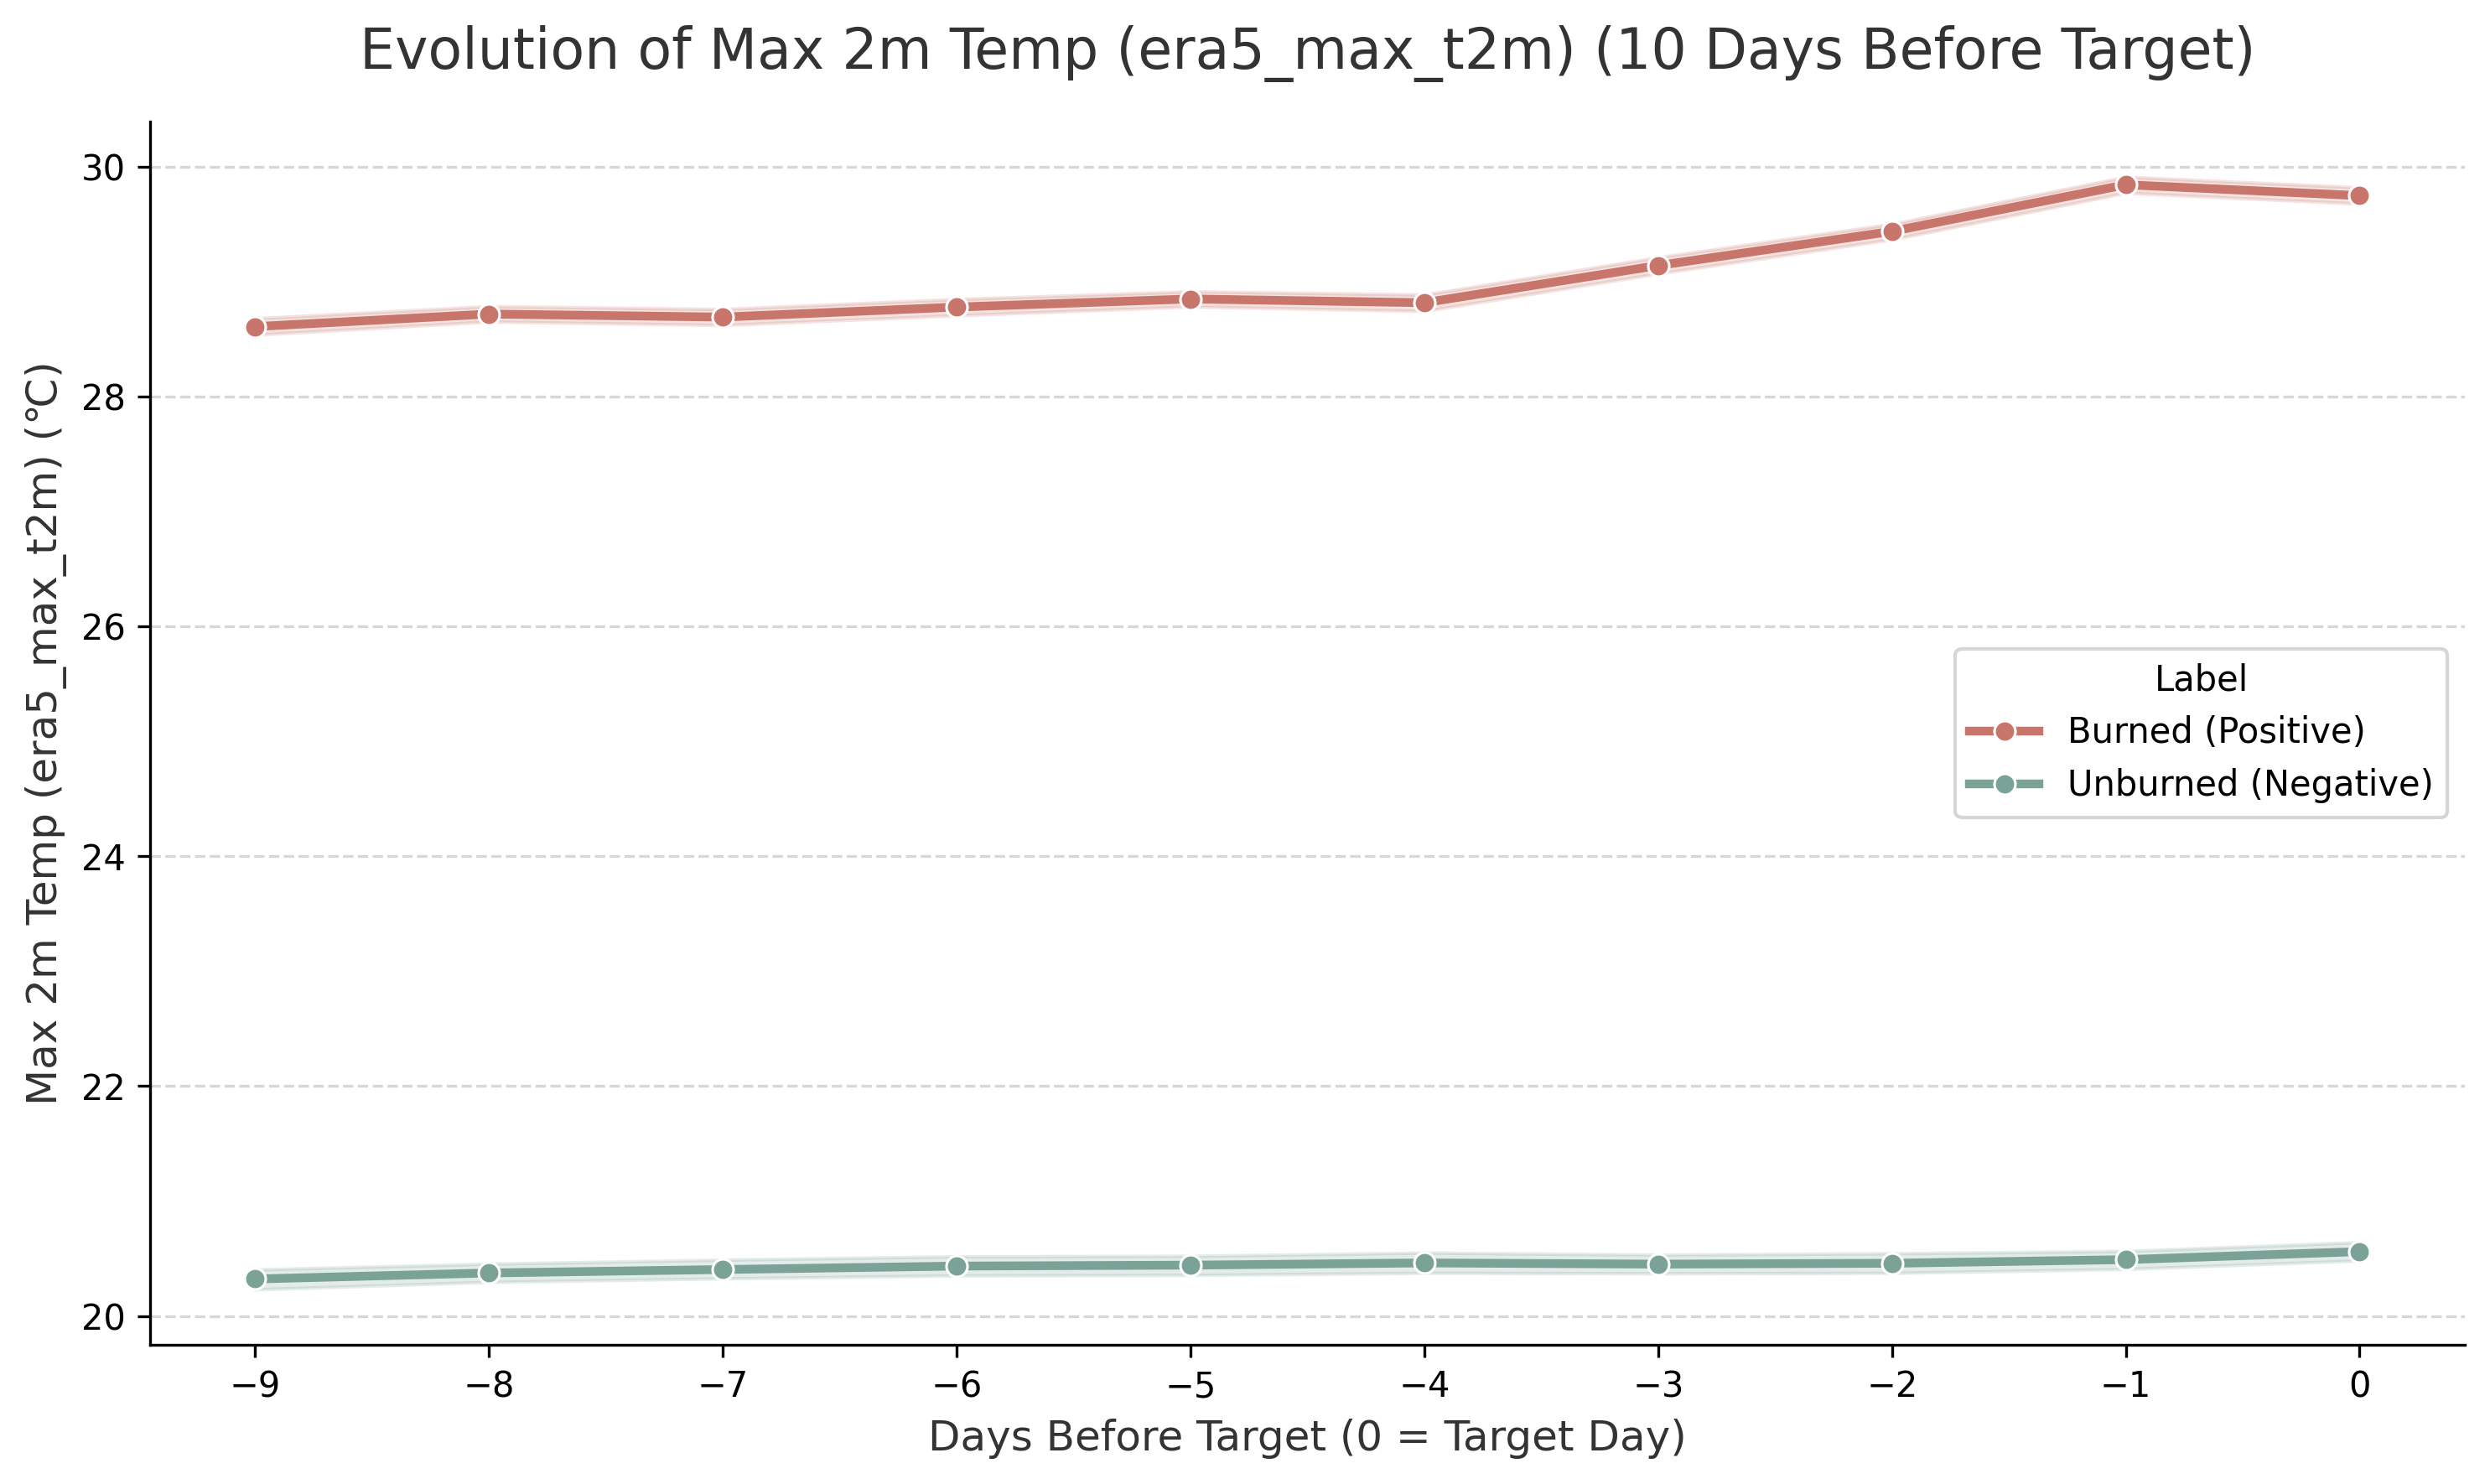

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 定义特征名称及其对应的单位，方便画图时自动加标签
feature_names = [
    '1 km 16 days NDVI',
    'LST_Day_1km',
    'LST_Night_1km',
    'Max Dewpoint Temp (era5_max_d2m)',
    'Max 2m Temp (era5_max_t2m)',
    'Max Surface Pressure (era5_max_sp)',
    'Max Total Precipitation (era5_max_tp)',
    'Soil Moisture (sminx)',
    'Max Wind Speed (era5_max_wind_speed)',
    'Min Relative Humidity (era5_min_rh)'
]

def plot_10d_evolution(feature_idx, pos_data_10d, neg_data_10d):
    """
    🔥 修正版：通过手动映射列名解决时间轴反转问题
    """
    # 【核心逻辑】：
    # 数据索引 0 对应物理时间 0 (当天)
    # 数据索引 9 对应物理时间 -9 (九天前)
    # 因此，DataFrame 的列名顺序必须与数据数组的物理意义严格对齐
    correct_time_mapping = [0, -1, -2, -3, -4, -5, -6, -7, -8, -9]
    
    feature_name = feature_names[feature_idx]
    
    # 针对温度特征 (K 转 ℃) 的处理
    if 'Temp' in feature_name or 'd2m' in feature_name or 'LST' in feature_name:
        pos_data_10d = pos_data_10d - 273.15
        neg_data_10d = neg_data_10d - 273.15
        ylabel = f'{feature_name} (℃)'
    else:
        ylabel = feature_name
        
    # 构建长格式 DataFrame
    # 此时 columns=correct_time_mapping 确保了数组第一个值被标记为 0，最后一个值被标记为 -9
    df_pos = pd.DataFrame(pos_data_10d, columns=correct_time_mapping).melt(
        var_name='Days Before Target', value_name='Value'
    )
    df_pos['Label'] = 'Burned (Positive)'
    
    df_neg = pd.DataFrame(neg_data_10d, columns=correct_time_mapping).melt(
        var_name='Days Before Target', value_name='Value'
    )
    df_neg['Label'] = 'Unburned (Negative)'
    
    df_ts = pd.concat([df_pos, df_neg], ignore_index=True)
    
    # 绘图
    plt.figure(figsize=(10, 6), dpi=300)
    academic_palette = {"Burned (Positive)": "#C8756B", "Unburned (Negative)": "#7BA297"}
    
    # Seaborn 的 lineplot 会自动根据 x 轴数值大小（-9 到 0）进行从左到右的排序绘制
    sns.lineplot(
        data=df_ts, x='Days Before Target', y='Value', 
        hue='Label', palette=academic_palette,
        marker='o', linewidth=2.5, errorbar='ci'
    )
    
    plt.title(f'Evolution of {feature_name} (10 Days Before Target)', fontsize=16, pad=15, color='#333333')
    plt.xlabel('Days Before Target (0 = Target Day)', fontsize=12, color='#333333')
    plt.ylabel(ylabel, fontsize=12, color='#333333')
    
    # 强制固定 X 轴刻度顺序
    plt.xticks(np.arange(-9, 1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()
    
# ======== 使用示例 ========
# 假设你之前在循环中提取了 era5_max_t2m (索引 4) 的 10 天数据：
pos_t2m_10d = np.array([data_dynamic[4, :, 12, 12] for _, data_dynamic, _, label, _ in eda_data if label == 1])
neg_t2m_10d = np.array([data_dynamic[4, :, 12, 12] for _, data_dynamic, _, label, _ in eda_data if label == 0])

# 然后直接调用：
plot_10d_evolution(4, pos_t2m_10d, neg_t2m_10d)  # 画最高温度

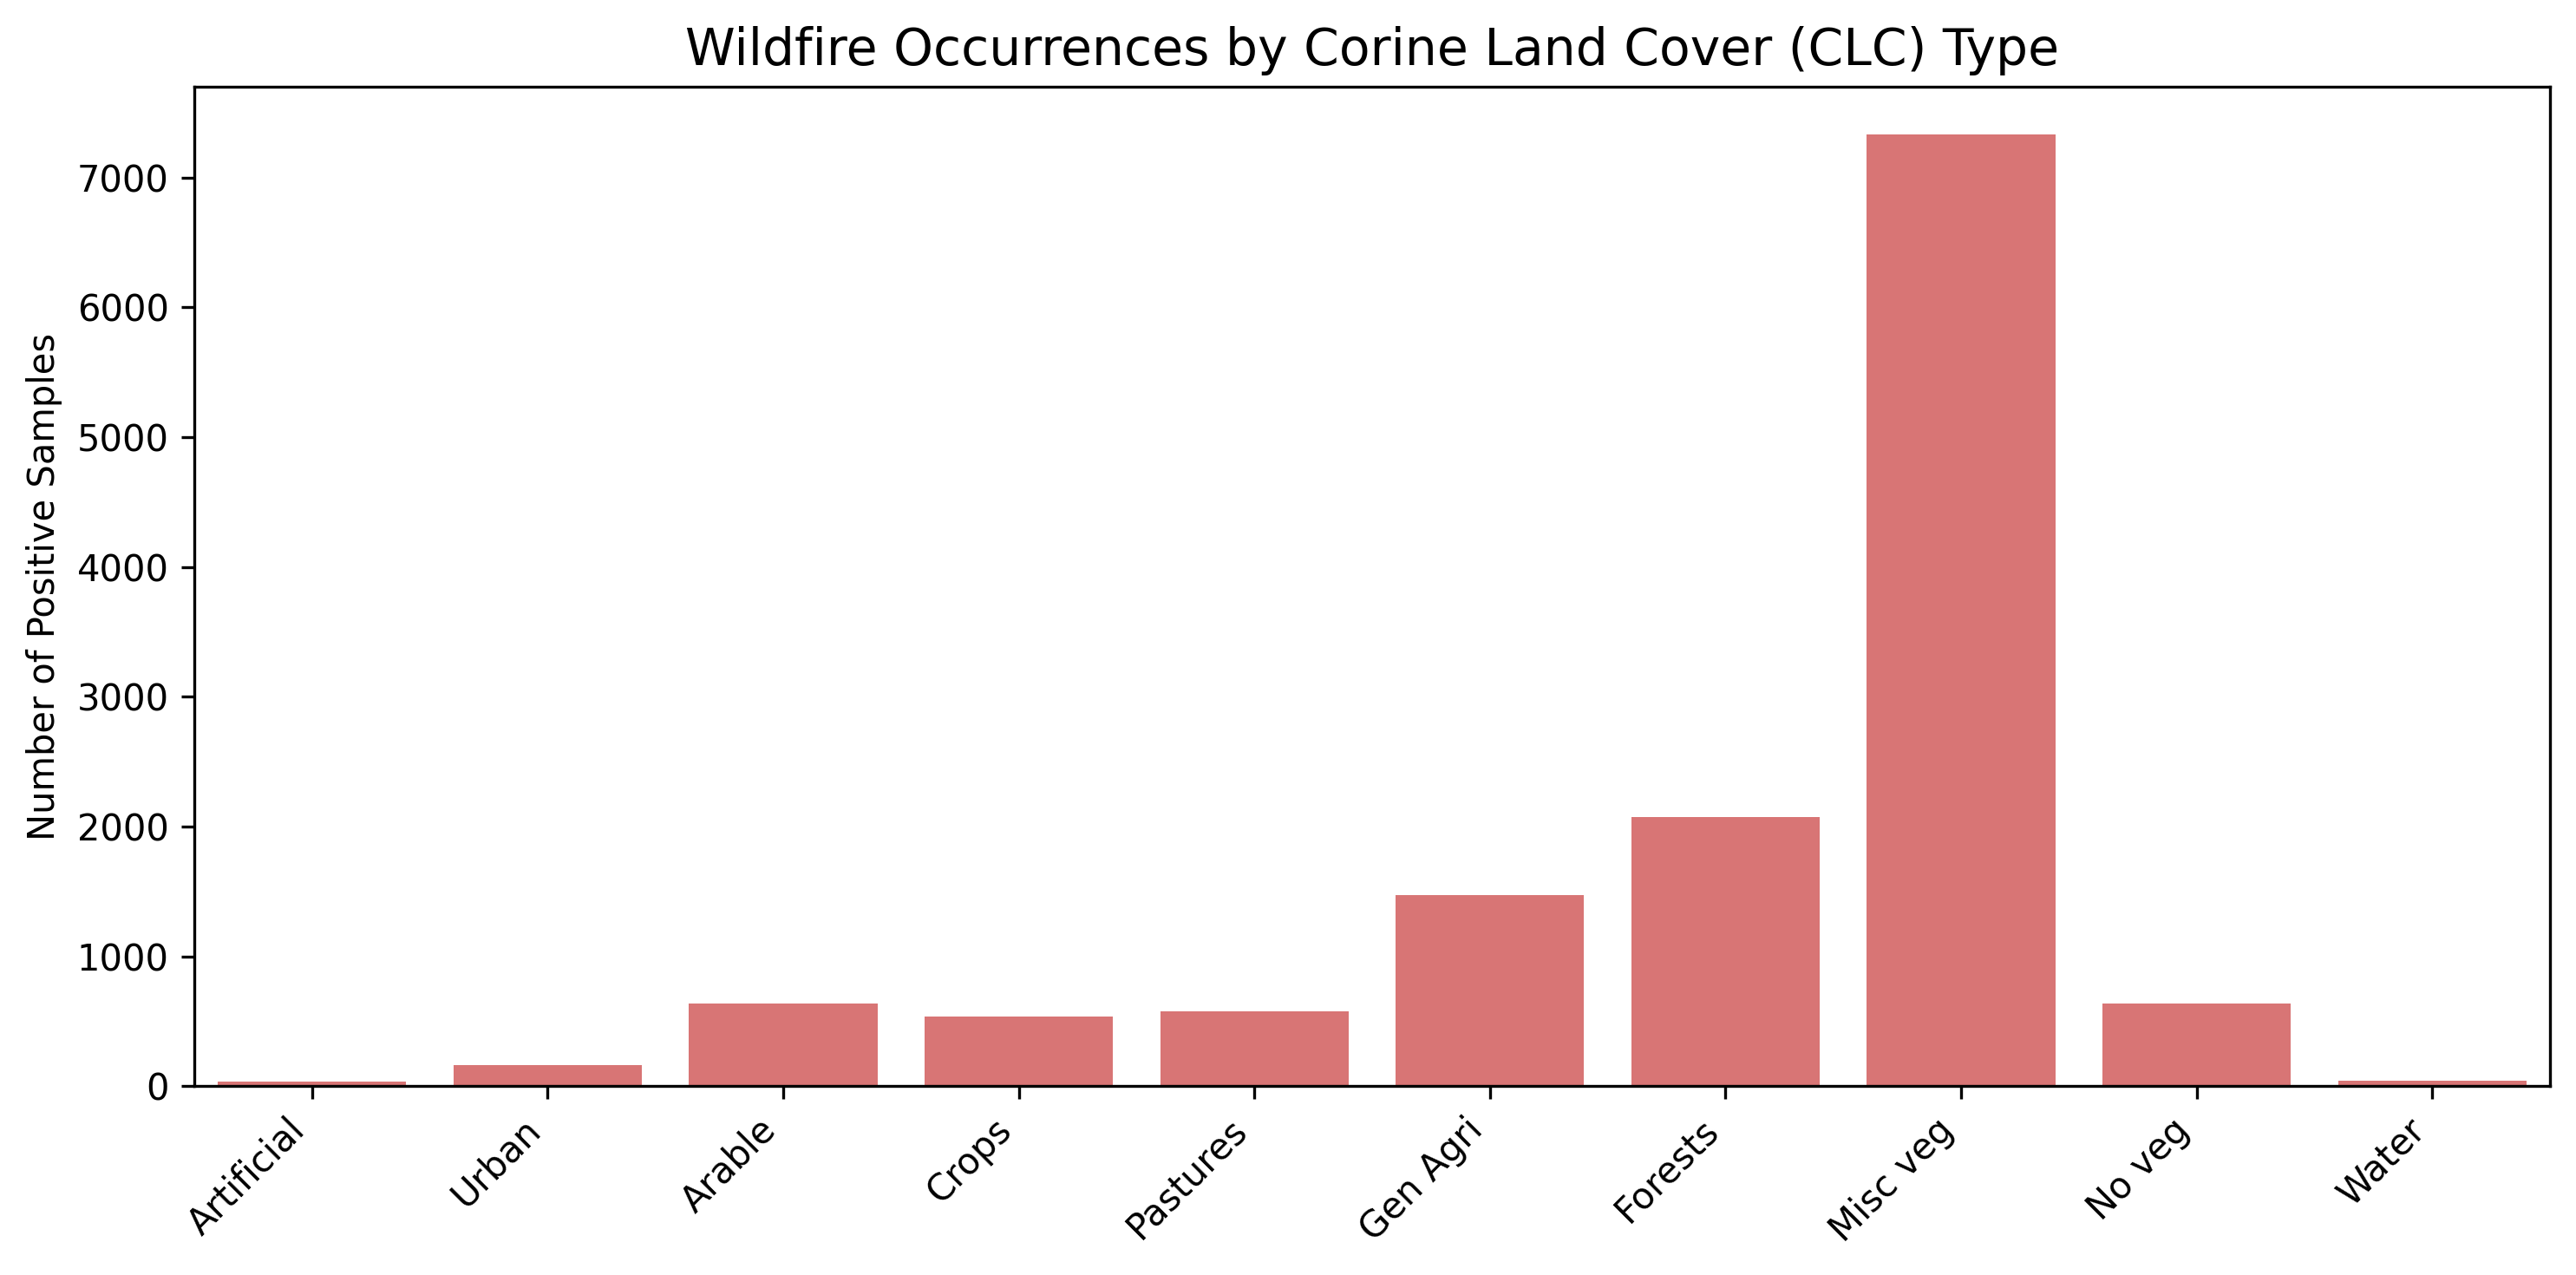

In [20]:
clc_names = ['Artificial', 'Urban', 'Arable', 'Crops', 'Pastures', 
             'Gen Agri', 'Forests', 'Misc veg', 'No veg', 'Water']

# np.argmax 将 One-hot 编码转回 0-9 的类别索引
pos_clc_classes = np.argmax(pos_clc, axis=1)

# 计算每个类别的频次
pos_counts = [np.sum(pos_clc_classes == c) for c in range(10)]

plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(x=clc_names, y=pos_counts, color="#e86565")
plt.title('Wildfire Occurrences by Corine Land Cover (CLC) Type', fontsize=14)
plt.ylabel('Number of Positive Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

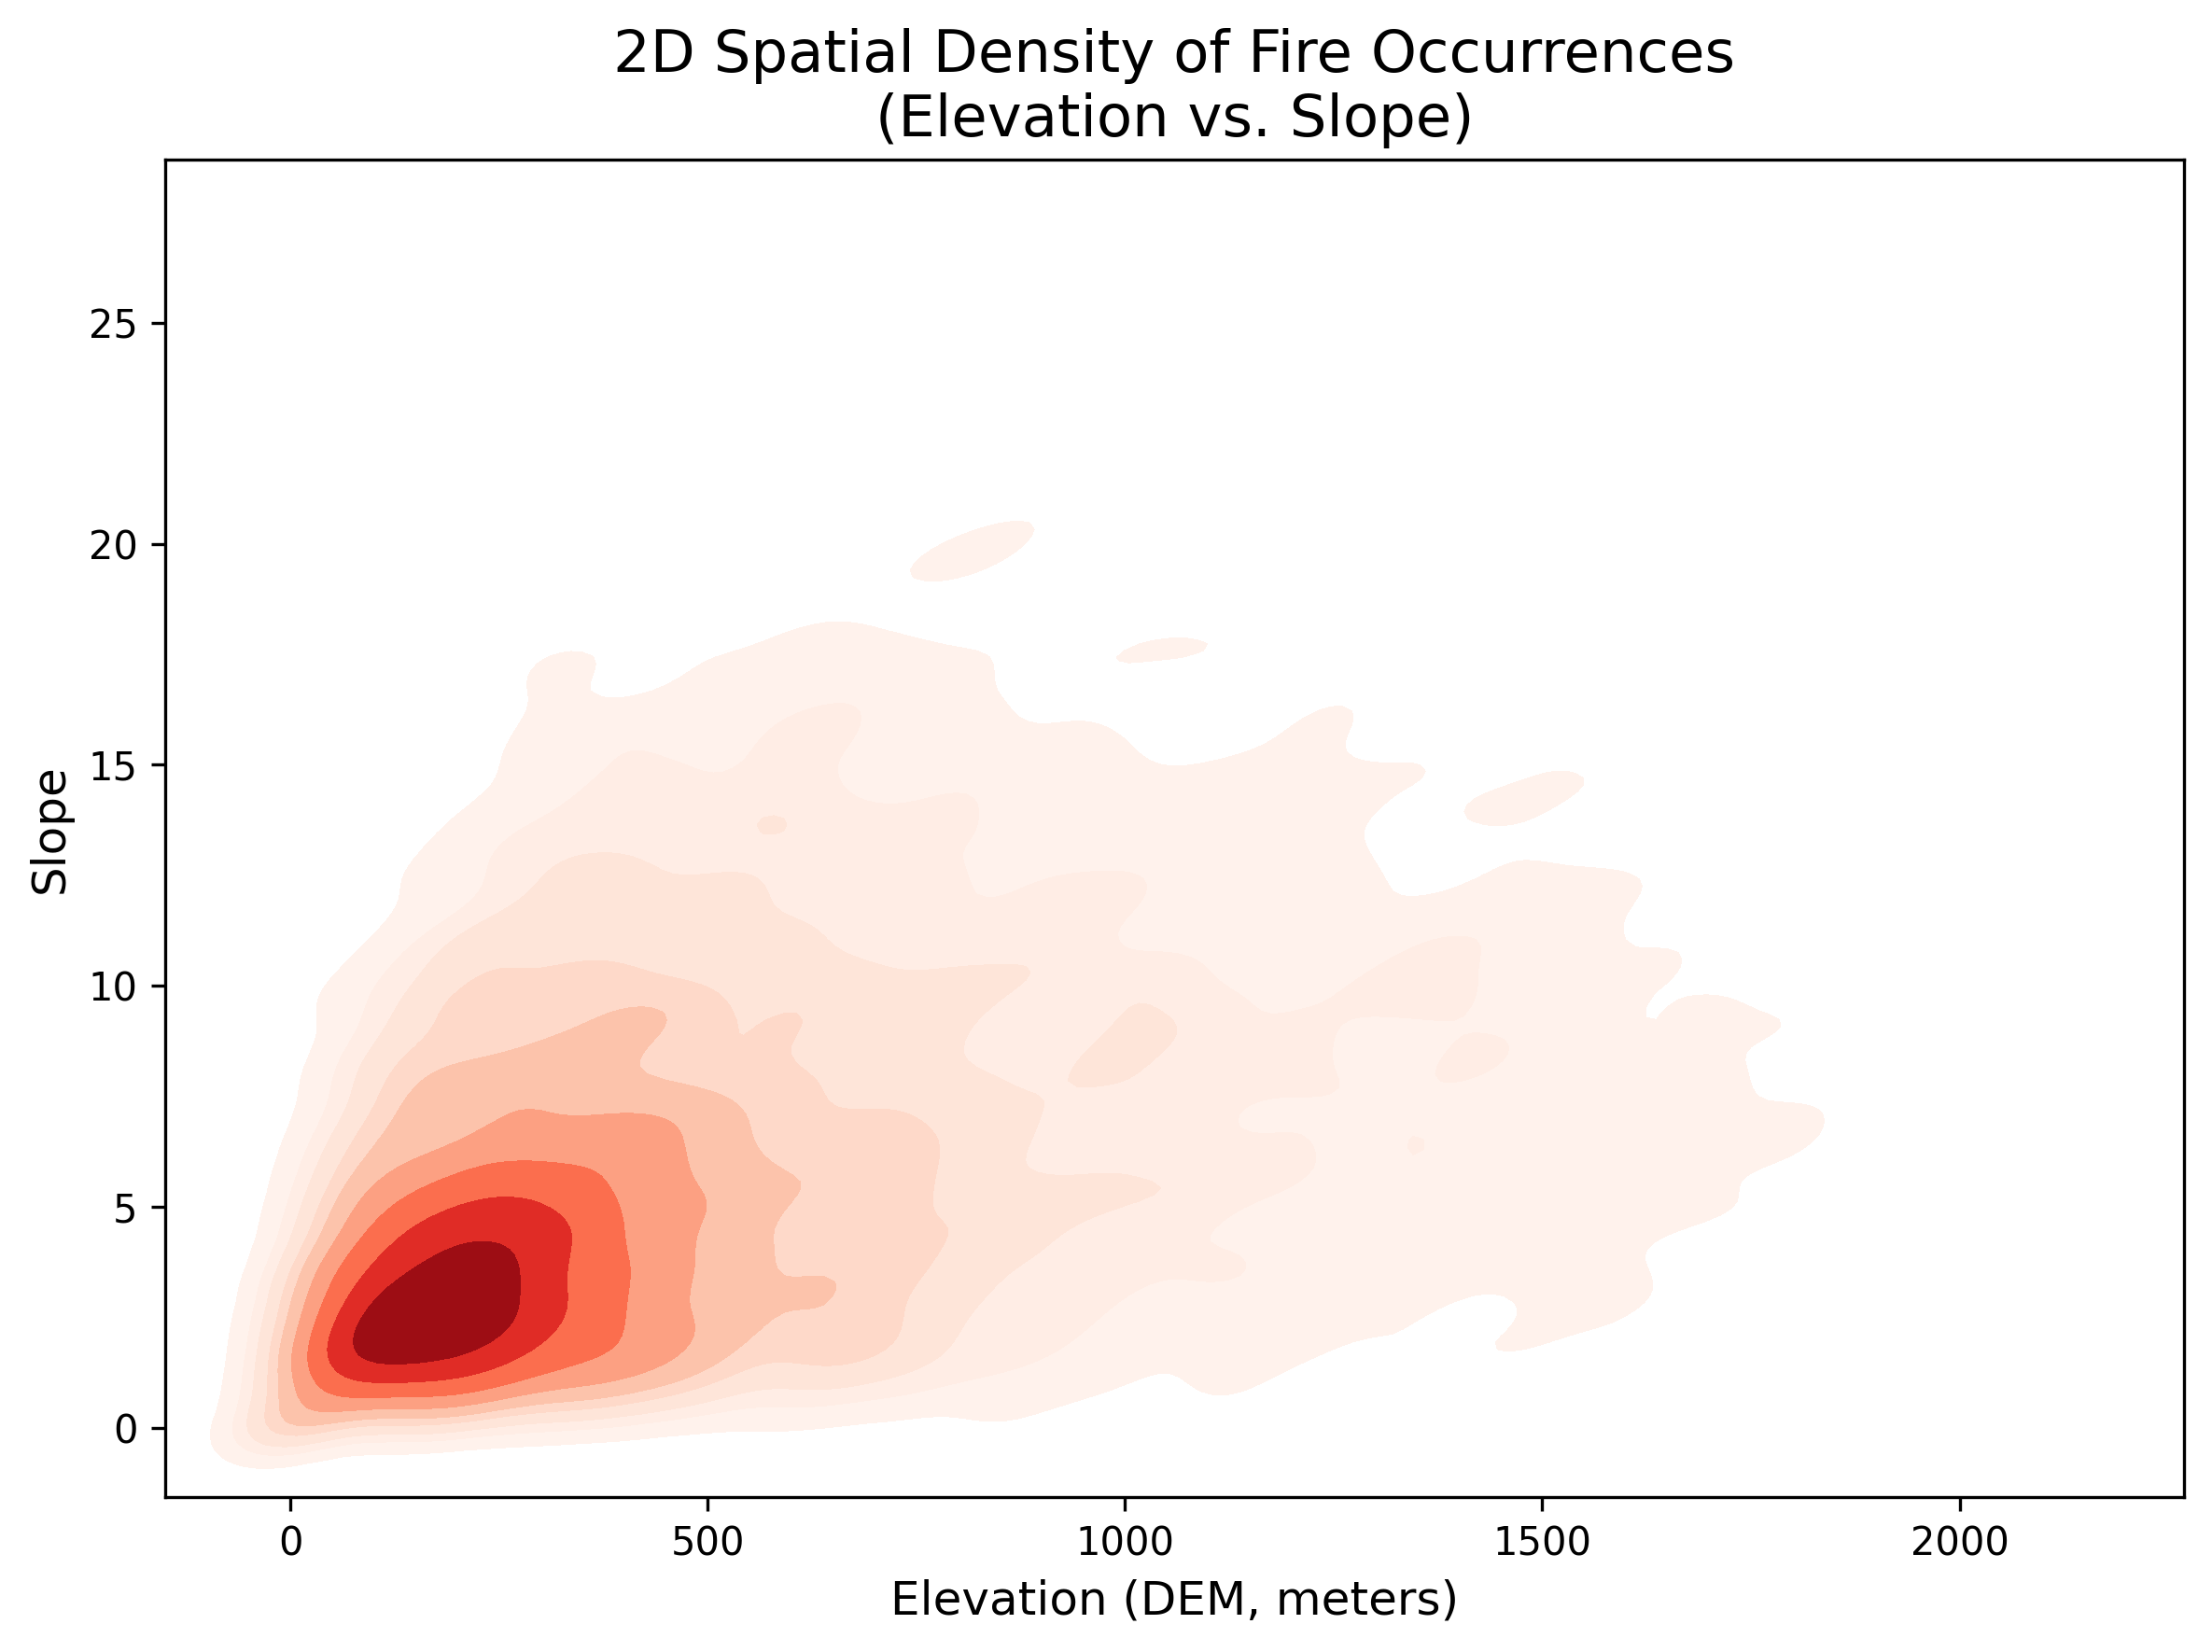

In [21]:
import numpy as np

# 1. 提取正样本的静态特征 (只取中心点 [12, 12])
pos_static_center = []
for i in range(num_samples): 
    data_static, _, _, label, _ = eda_data[i]
    if label == 1:
        pos_static_center.append(data_static[:, 12, 12])

pos_static_center = np.array(pos_static_center)

# dem_mean 是第 0 个通道, slope_mean 是第 1 个通道
pos_dem = pos_static_center[:, 0]
pos_slope = pos_static_center[:, 1]

# 2. 绘制 2D 核密度图
plt.figure(figsize=(8, 6), dpi=300)
# fill=True 填充颜色，thresh 设置轮廓显示的最低阈值防止边缘太碎
sns.kdeplot(x=pos_dem, y=pos_slope, cmap="Reds", fill=True, bw_adjust=0.6, thresh=0.05)

plt.title('2D Spatial Density of Fire Occurrences\n(Elevation vs. Slope)', fontsize=15)
plt.xlabel('Elevation (DEM, meters)', fontsize=12)
plt.ylabel('Slope', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
years_all = []
months_all = []
labels_all = []

# 极速遍历全量数据，只取时间和标签（不读取笨重的 npy 矩阵）
print("正在统计全量样本的时间分布...")
for i in range(len(eda_data)):
    # 直接调用 get_time 和读取 labels 列表，不调用 __getitem__
    year, month, _ = eda_data.get_time(i)
    _, label = eda_data.files[i]
    
    years_all.append(year)
    months_all.append(month)
    labels_all.append(label)

print("时间分布提取完成！")

正在统计全量样本的时间分布...
时间分布提取完成！


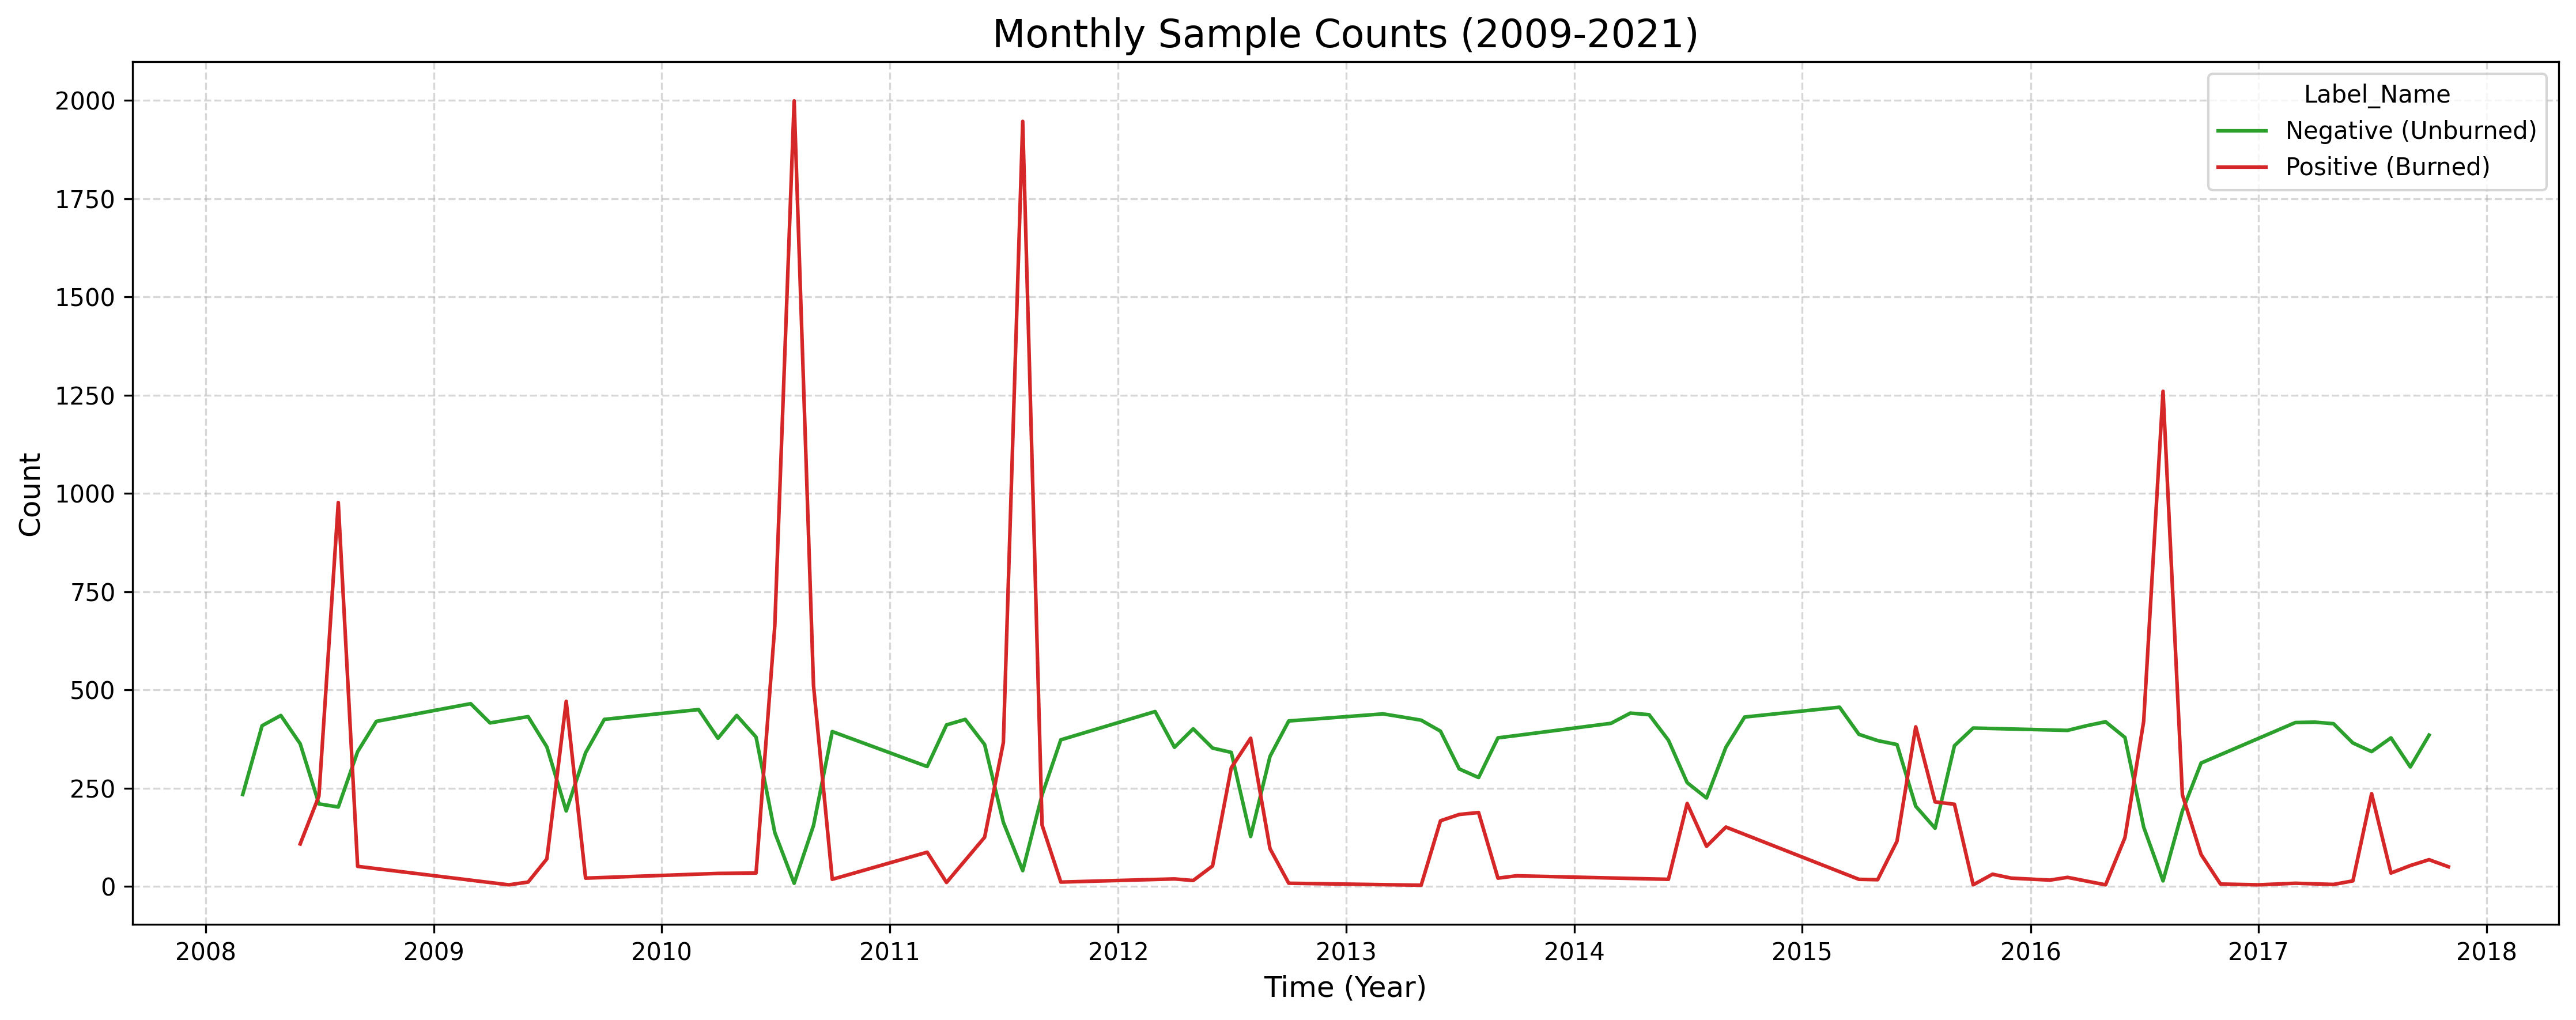

In [15]:
# 1. 组装全量时间数据
df_ts = pd.DataFrame({
    'Year': years_all,
    'Month': months_all,
    'Label': labels_all
})
df_ts['Label'] = df_ts['Label'].astype(int)
df_ts['Label_Name'] = df_ts['Label'].map({1: 'Positive (Burned)', 0: 'Negative (Unburned)'})

# 创建一个用于排序和画图的虚拟时间列 (例如 2019-01)
df_ts['YearMonth'] = pd.to_datetime(df_ts['Year'].astype(str) + '-' + df_ts['Month'].astype(str))

# 统计每个月、每个标签的数量
ts_counts = df_ts.groupby(['YearMonth', 'Label_Name']).size().reset_index(name='Count')
ts_counts = ts_counts.sort_values(by='YearMonth')

# 2. 画图
plt.figure(figsize=(15, 6), dpi=300)

sns.lineplot(data=ts_counts, x='YearMonth', y='Count', hue='Label_Name',
             palette={"Positive (Burned)": "#d62728", "Negative (Unburned)": "#2ca02c"},
             linewidth=1.5)

plt.title('Monthly Sample Counts (2009-2021)', fontsize=16)
plt.xlabel('Time (Year)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # 用于显示进度条
from FireCube_dataloader import FireCubeLoader

# 1. 必须先把特征列表定义出来（与你训练时保持完全一致）
dynamic_features = [
    '1 km 16 days NDVI',
    'LST_Day_1km',
    'LST_Night_1km',
    'era5_max_d2m',
    'era5_max_t2m',
    'era5_max_sp',
    'era5_max_tp',
    'sminx',
    'era5_max_wind_speed',
    'era5_min_rh'
]

static_features = [
    'dem_mean',
    'slope_mean',
    'roads_distance',
    'waterway_distance',
    'population_density'
]

clc_features = ['clc_' + str(c) for c in range(10)]

# 2. 初始化专门用于分析的 DataLoader
# 【注意】is_scale=False, is_aug=False 保证原始物理数值，且必须传入上面定义的三个 features！
eda_data = FireCubeLoader(
    root='./datasets/datasets_grl/npy/spatiotemporal', 
    mode='train', 
    is_scale=False, 
    is_aug=False, 
    is_shuffle=True, 
    seed=42,
    dynamic_features=dynamic_features,   # ✅ 补充传入动态特征
    static_features=static_features,     # ✅ 补充传入静态特征
    clc_features=clc_features            # ✅ 补充传入土地覆盖特征
)
# 2. 准备容器收集中心像素 [12, 12] 的数据
pos_dynamic_target_day = [] # 正样本，目标日的所有动态特征
neg_dynamic_target_day = [] 
pos_sminx_10d = []          # 正样本，10天的土壤湿度序列 (特征索引为7)
neg_sminx_10d = []
pos_clc = []                # 正样本，中心点CLC
neg_clc = []
months = []
labels = []

# 为了画图速度，我们抽取 5000 个样本（你也可以设为全集 len(eda_data)）
num_samples = len(eda_data)

print(f"正在从 {num_samples} 个样本中提取中心像素特征用于可视化...")
for i in tqdm(range(num_samples)):
    data_static, data_dynamic, data_clc, label, data_time = eda_data[i]
    _, month, _ = eda_data.get_time(i)
    
    months.append(month)
    labels.append(label)
    
    # 提取中心点 [12, 12] 的数据
    if label == 1:
        pos_dynamic_target_day.append(data_dynamic[:, 0, 12, 12]) # 取第10天(索引9)的所有动态特征
        pos_sminx_10d.append(data_dynamic[7, :, 12, 12])          # 取10天的 sminx (索引7)
        pos_clc.append(data_clc[:, 12, 12])
    else:
        neg_dynamic_target_day.append(data_dynamic[:, 9, 12, 12])
        neg_sminx_10d.append(data_dynamic[7, :, 12, 12])
        neg_clc.append(data_clc[:, 12, 12])

# 转为 numpy 方便处理
pos_dynamic_target_day = np.array(pos_dynamic_target_day)
neg_dynamic_target_day = np.array(neg_dynamic_target_day)
pos_sminx_10d = np.array(pos_sminx_10d)
neg_sminx_10d = np.array(neg_sminx_10d)
pos_clc = np.array(pos_clc)
neg_clc = np.array(neg_clc)

正在从 40554 个样本中提取中心像素特征用于可视化...


100%|██████████| 40554/40554 [01:35<00:00, 425.93it/s]


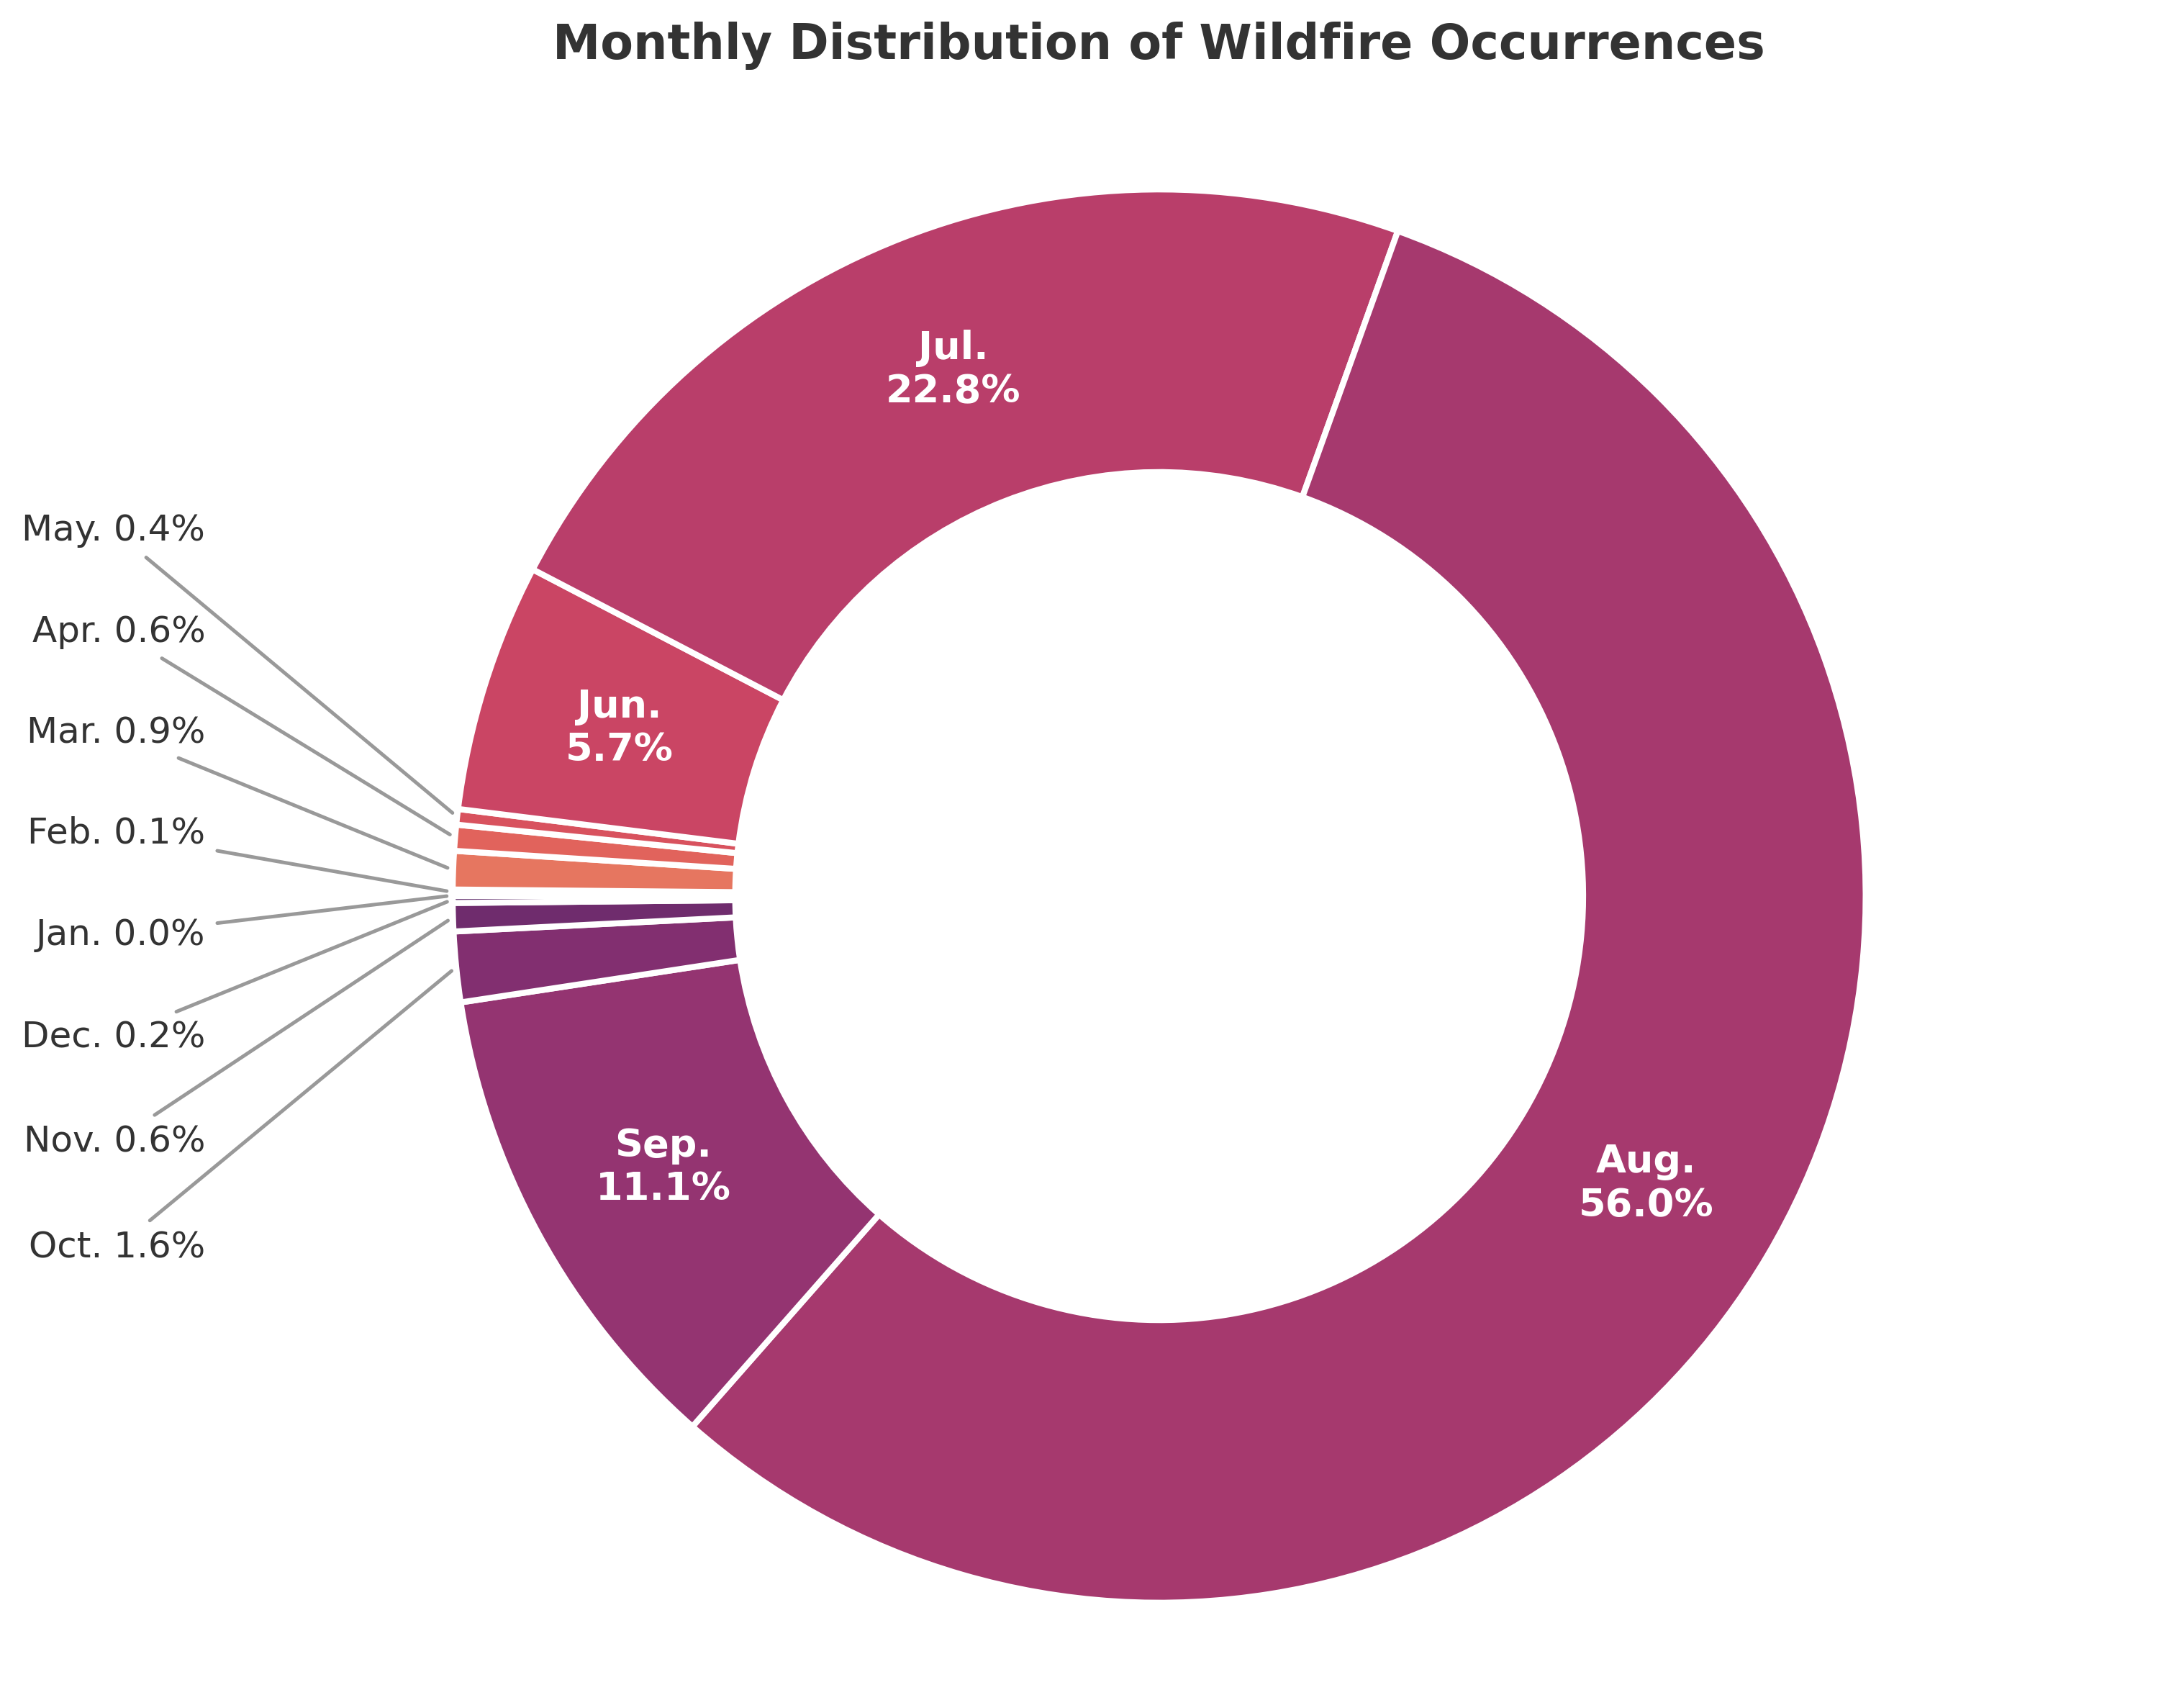

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# =====================================================================
# 生成饼图所需的统计数据
# =====================================================================

# 1. 将月份和标签转为 Pandas Series 方便统计
df_stats = pd.DataFrame({'Month': months, 'Label': labels})

# 2. 筛选出所有正样本 (Label == 1)
df_pos_only = df_stats[df_stats['Label'] == 1]

# 3. 统计每个月份出现的次数
# 使用 value_counts 并按月份排序，确保 1月到12月顺序正确
pos_counts = df_pos_only['Month'].value_counts().sort_index()

# 4. 生成 month_names (转化为中文或英文简写)
# 映射字典：将数字 1-12 映射为字符串
month_map = {
    1: 'Jan.', 2: 'Feb.', 3: 'Mar.', 4: 'Apr.', 5: 'May.', 6: 'Jun.',
    7: 'Jul.', 8: 'Aug.', 9: 'Sep.', 10: 'Oct.', 11: 'Nov.', 12: 'Dec.'
}

# 获取月份名称列表 (只取数据中存在的月份)
month_names = [month_map[m] for m in pos_counts.index]

# 5. 获取对应的统计数值
pos_vals = pos_counts.values.tolist()

df_pos_pie = pd.DataFrame({'Month': month_names, 'Count': pos_vals})
df_pos_pie = df_pos_pie[df_pos_pie['Count'] > 0].reset_index(drop=True)

# 1. 画图设置 (高度稍微拉大一点，给底部的标签留足空间)
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)

colors = sns.color_palette("flare", n_colors=len(df_pos_pie))

# 2. 绘制饼图
wedges, _ = ax.pie(
    df_pos_pie['Count'], 
    startangle=180,             # 🌟 核心改动：把起点转到 6 点钟方向！
    counterclock=False,         
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) 
)

# 3. 智能标签排版逻辑 (算法保留，用于把线拉直、对齐)
total = df_pos_pie['Count'].sum()
labels_info = []

for i, p in enumerate(wedges):
    pct = (df_pos_pie['Count'].iloc[i] / total) * 100
    month_label = df_pos_pie['Month'].iloc[i]
    
    ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    
    labels_info.append({
        'text': f"{month_label} {pct:.1f}%" if pct < 5.0 else f"{month_label}\n{pct:.1f}%",
        'x': x, 
        'y': y, 
        'pct': pct
    })

outer_right = [d for d in labels_info if d['pct'] < 5.0 and d['x'] >= 0]
outer_left  = [d for d in labels_info if d['pct'] < 5.0 and d['x'] < 0]

outer_right.sort(key=lambda d: d['y'], reverse=True)
outer_left.sort(key=lambda d: d['y'], reverse=True)

# 物理弹簧算法 (防止重叠)
def resolve_overlaps(label_list, min_dist=0.15):
    for d in label_list:
        d['y_text'] = d['y'] * 1.1 
    for _ in range(20): 
        for i in range(len(label_list) - 1):
            diff = label_list[i]['y_text'] - label_list[i+1]['y_text']
            if diff < min_dist:
                overlap = min_dist - diff
                label_list[i]['y_text'] += overlap / 2
                label_list[i+1]['y_text'] -= overlap / 2

resolve_overlaps(outer_right)
resolve_overlaps(outer_left)

# 4. 开始绘制文字和引线
# 内圈大标签
for d in labels_info:
    if d['pct'] >= 5.0:
        ax.text(d['x'] * 0.8, d['y'] * 0.8, d['text'], 
                ha='center', va='center', fontsize=13, color='white', fontweight='bold')

# 外圈引线
kw = dict(arrowprops=dict(arrowstyle="-", color="#999999", lw=1.2), zorder=0, va="center", fontsize=12, color="#333333")

for d in outer_right:
    ax.annotate(d['text'], xy=(d['x'], d['y']), xytext=(1.35, d['y_text']), ha='left', **kw)

for d in outer_left:
    ax.annotate(d['text'], xy=(d['x'], d['y']), xytext=(-1.35, d['y_text']), ha='right', **kw)

# 5. 标题与排版优化
plt.title('Monthly Distribution of Wildfire Occurrences', 
          fontsize=16, pad=20, fontweight='bold', color="#333333")

ax.axis('equal') 
# 适当调整边距，防止上下元素被切掉
plt.subplots_adjust(top=0.9, bottom=0.1)
plt.show()

/tmp/ipykernel_4783/2774699604.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='Label', y='Max 2m Temperature',


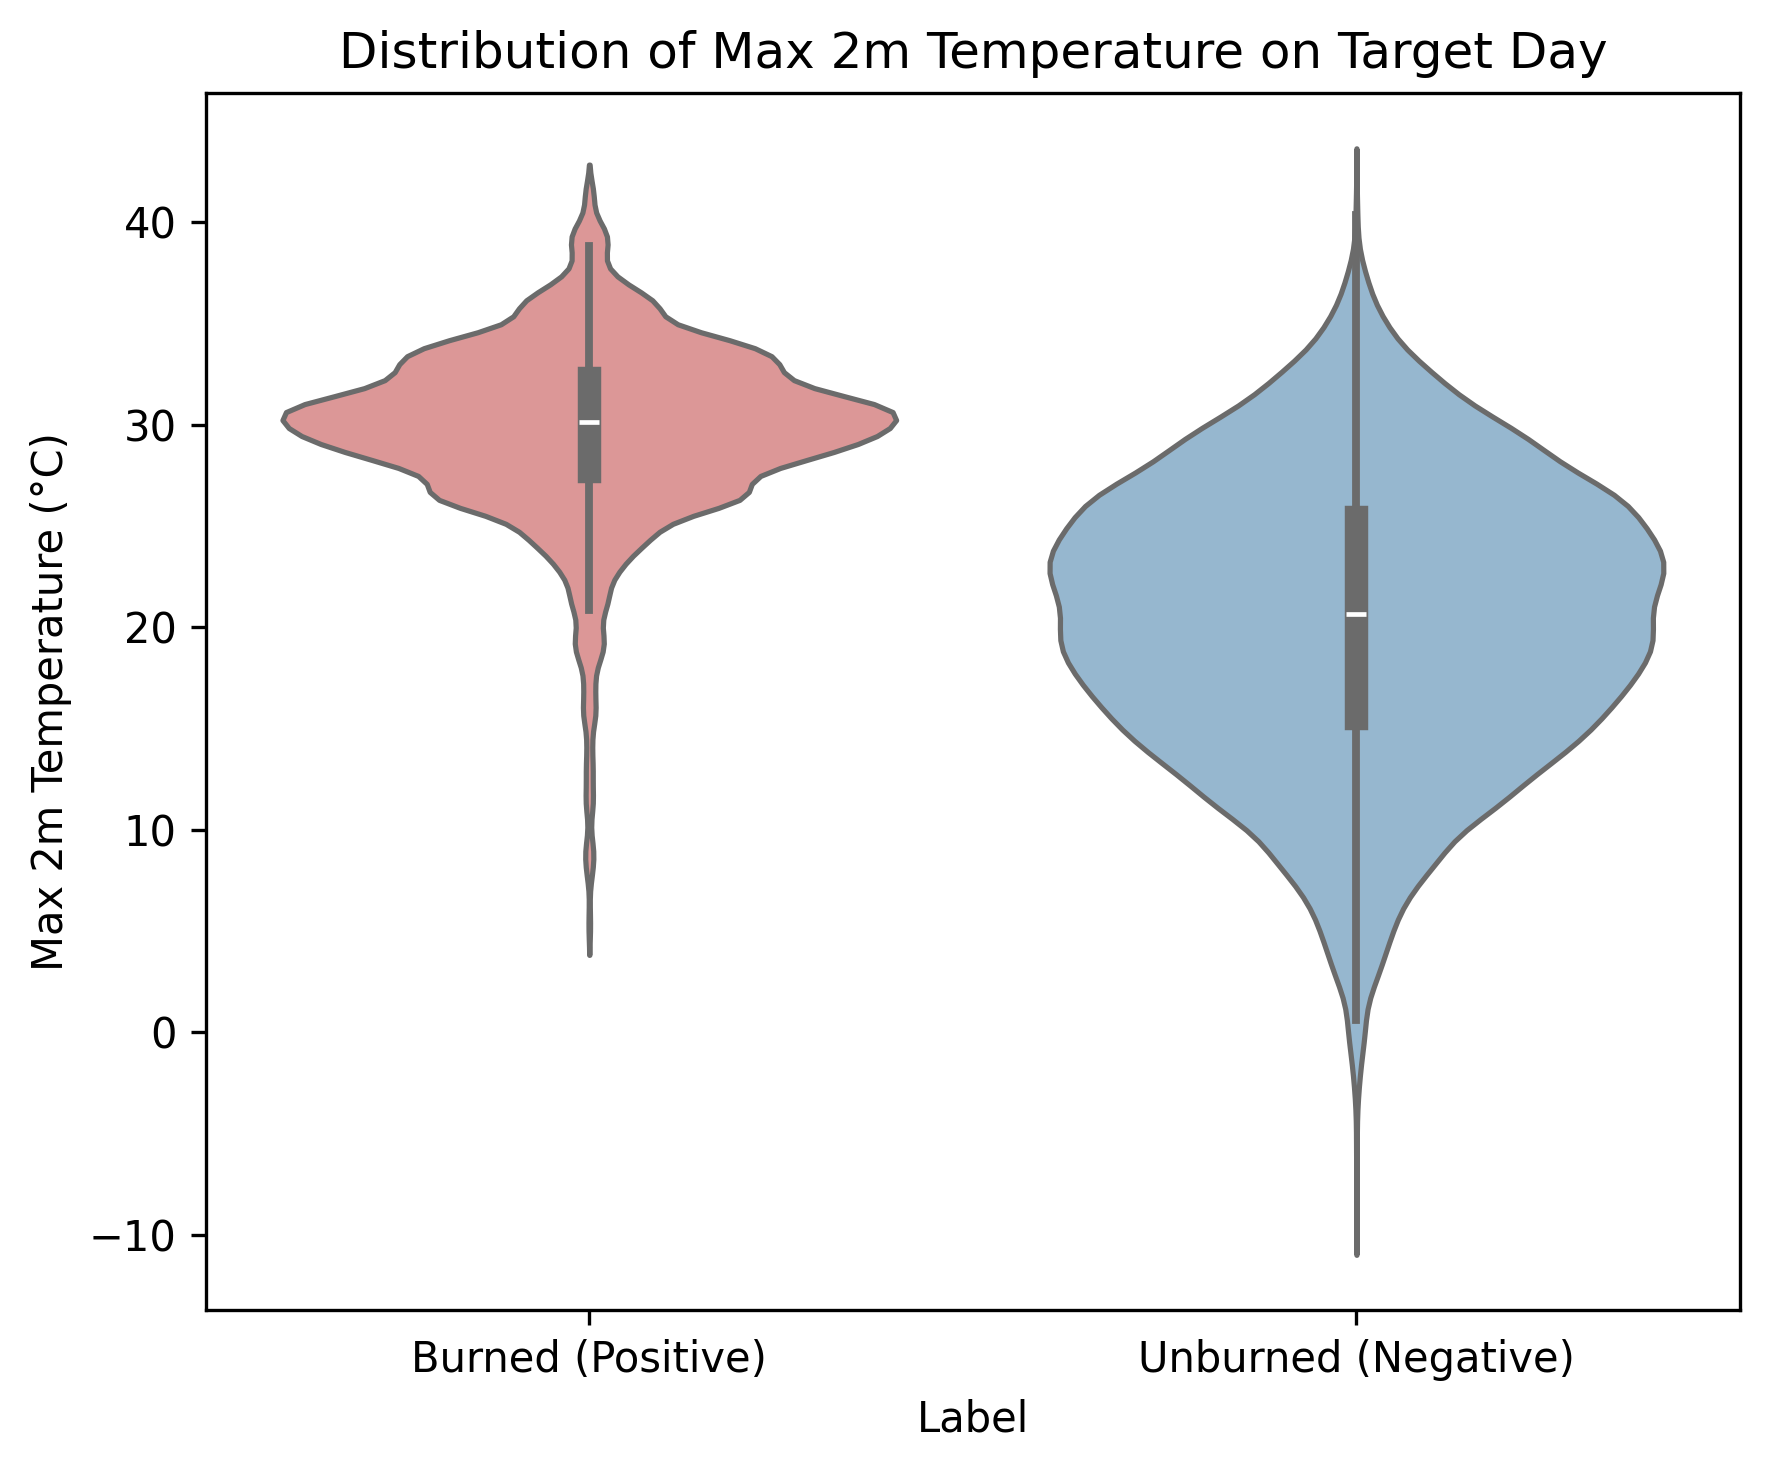

In [ ]:
# 提取特征索引 4 (era5_max_t2m)
pos_temp = pos_dynamic_target_day[:, 4]
neg_temp = neg_dynamic_target_day[:, 4]

pos_temp_c = pos_temp - 273.15
neg_temp_c = neg_temp - 273.15

df_temp = pd.DataFrame({
    'Max 2m Temperature': np.concatenate([pos_temp_c, neg_temp_c]),
    'Label': ['Burned (Positive)'] * len(pos_temp_c) + ['Unburned (Negative)'] * len(neg_temp_c)
})

plt.figure(figsize=(6, 5), dpi=300)
# 方案一：延续莫兰迪配色（强烈推荐，保持全篇统一）
sns.violinplot(data=df_temp, x='Label', y='Max 2m Temperature', 
               palette={"Burned (Positive)": "#E88B8B", "Unburned (Negative)": "#8CB8D9"})
plt.title('Distribution of Max 2m Temperature on Target Day', fontsize=12)
plt.ylabel('Max 2m Temperature (°C)')
plt.tight_layout()
plt.show()

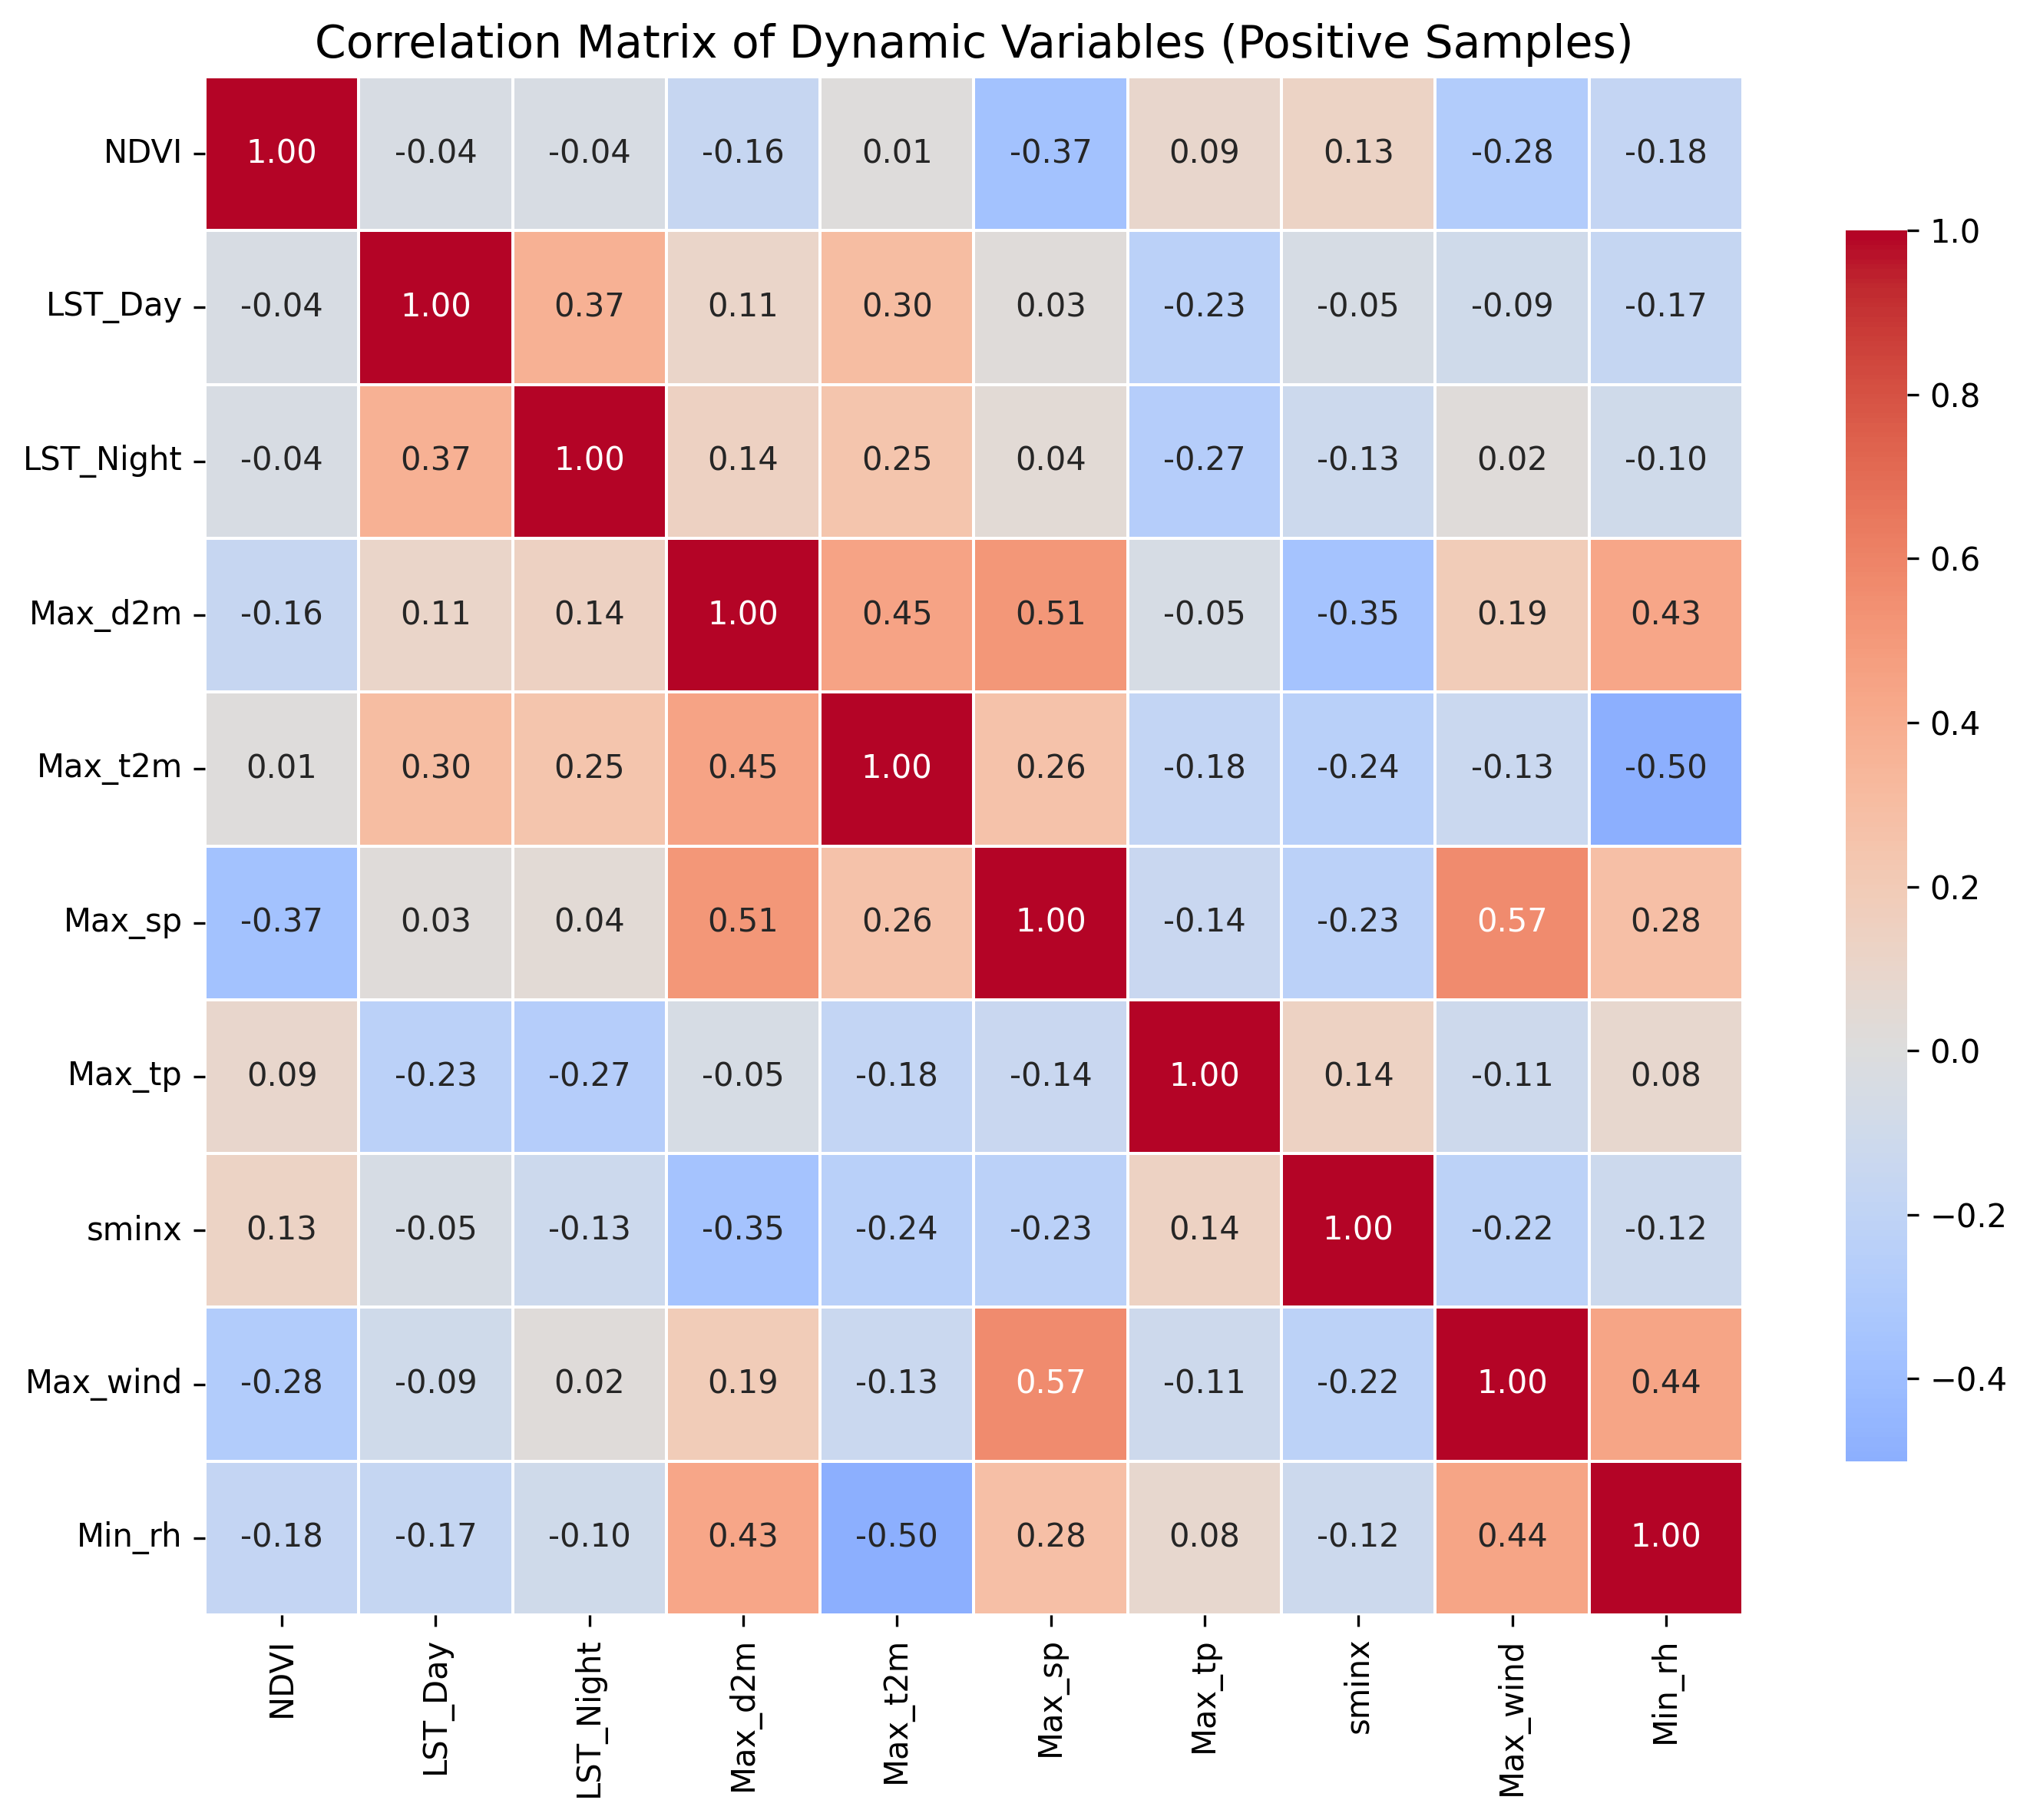

In [ ]:
dynamic_feature_names = [
    'NDVI', 'LST_Day', 'LST_Night', 'Max_d2m', 'Max_t2m', 
    'Max_sp', 'Max_tp', 'sminx', 'Max_wind', 'Min_rh'
] # 为了图表美观，用简短名称

# 计算正样本特征的皮尔逊相关系数
df_corr = pd.DataFrame(pos_dynamic_target_day, columns=dynamic_feature_names)
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Dynamic Variables (Positive Samples)', fontsize=14)
plt.tight_layout()
plt.show()